
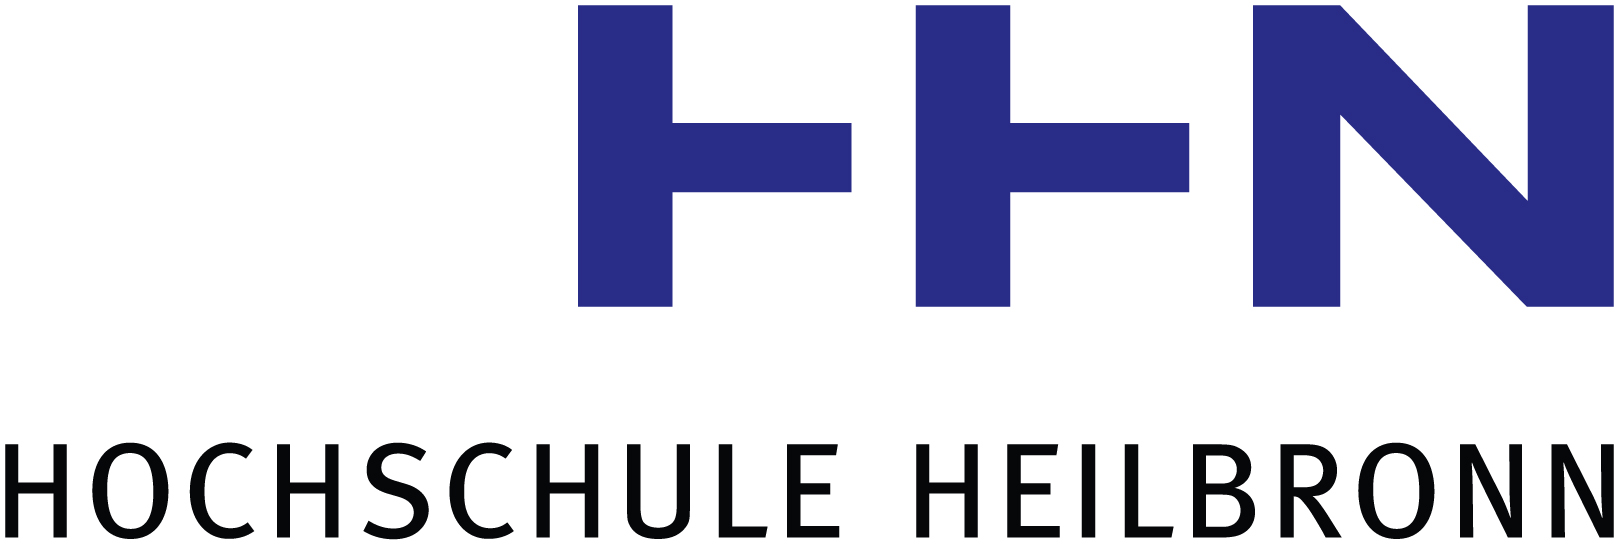


**MWI - Deep Learning**


# RQ2 (Portfolio Examination)

## Beyond Clean Data
#### *Comparing MLP and CNN Robustness to Image Perturbations*

**Due Date:** April 16, 2026  
**Team:** [Your Team Name]  
**Members:** [Name 1, Name 2]  


---

### Research Question

> *How do MLP and CNN differ in their robustness to systematic image perturbations on MNIST, and which types of perturbation cause which model to fail?*

---

**How to use this template:**
- This notebook runs **out of the box** and trains both an MLP and a CNN on MNIST.
- Look for `# TODO` markers -- these are the places where you need to add your experiments.
- The template provides: model definitions, training loop, perturbation helpers, and plotting functions.
- You should **reuse your training knowledge from RQ1** -- the loop is similar but simplified (no regularization focus).
- Your main creative work: **designing perturbations** and **analyzing failures**.

## 1. Setup and Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from copy import deepcopy
from PIL import Image
import scipy.ndimage
import os

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

Using device: cuda


## 2. Data Loading

We load MNIST and split into **train** (50,000), **validation** (10,000), and **test** (10,000).  
The test set is what we will perturb later -- the models never see any perturbed data during training.

Training samples:   50000
Validation samples: 10000
Test samples:       10000
Test images shape: torch.Size([10000, 28, 28])


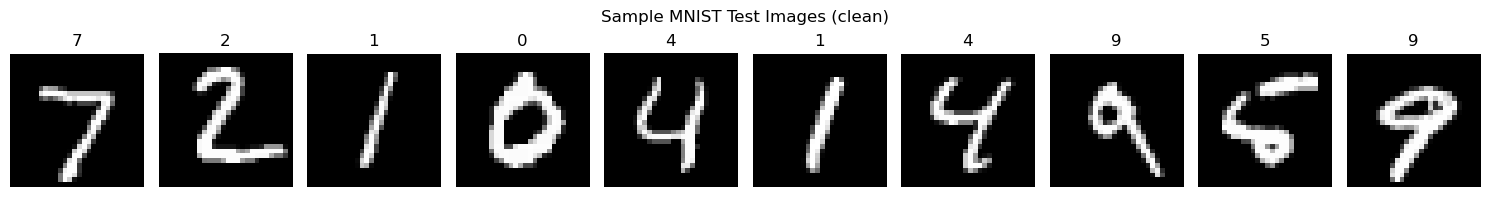

In [3]:
# MNIST normalization: mean=0.1307, std=0.3081
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))
])

full_train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_dataset, val_dataset = random_split(
    full_train_dataset, [50000, 10000],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Training samples:   {len(train_dataset)}')
print(f'Validation samples: {len(val_dataset)}')
print(f'Test samples:       {len(test_dataset)}')

# Also extract raw test images and labels as tensors (for perturbation later)
test_images = test_dataset.data.float() / 255.0   # [10000, 28, 28], range [0, 1]
test_labels = test_dataset.targets                  # [10000]
print(f'Test images shape: {test_images.shape}')

# Show sample images
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(test_images[i], cmap='gray')
    ax.set_title(f'{test_labels[i].item()}')
    ax.axis('off')
plt.suptitle('Sample MNIST Test Images (clean)')
plt.tight_layout()
plt.show()

## 3. Model Definitions

We define both an MLP and a CNN. Both are kept simple and train quickly on MNIST.

In [4]:
class MLP(nn.Module):
    """Multi-Layer Perceptron for MNIST.
    Flattens the 28x28 image and processes it through fully-connected layers.
    """
    def __init__(self, hidden_size=256, num_layers=2):
        super().__init__()
        layers = []
        in_features = 784  # 28 * 28
        for _ in range(num_layers):
            layers.extend([nn.Linear(in_features, hidden_size), nn.ReLU()])
            in_features = hidden_size
        layers.append(nn.Linear(in_features, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        return self.network(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


class CNN(nn.Module):
    """Simple CNN for MNIST.
    Uses convolutional layers to detect local features, then classifies.
    """
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Conv block 1: 1 -> 16 channels
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 -> 14x14
            # Conv block 2: 16 -> 32 channels
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14 -> 7x7
            # Conv block 3: 32 -> 64 channels
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7 -> 3x3
        )
        self.classifier = nn.Sequential(
            nn.Linear(64 * 3 * 3, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        if x.dim() == 3:  # [B, 28, 28] -> [B, 1, 28, 28]
            x = x.unsqueeze(1)
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


# Quick check
mlp = MLP(hidden_size=256, num_layers=2)
cnn = CNN()
print(f'MLP parameters: {mlp.count_parameters():,}')
print(f'CNN parameters: {cnn.count_parameters():,}')

MLP parameters: 269,322
CNN parameters: 98,442


## 4. Training and Evaluation Functions

A simple training loop (similar to RQ1, but without regularization options -- the focus here is robustness, not overfitting).

In [5]:
def train_model(model, train_loader, val_loader, num_epochs=20, lr=0.001, verbose=True):
    """Train a model on MNIST. Returns history dict and best validation accuracy."""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        # Train
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        train_loss = total_loss / total
        train_acc = 100.0 * correct / total

        # Validate
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        val_loss = total_loss / total
        val_acc = 100.0 * correct / total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())

        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'Epoch {epoch:2d}/{num_epochs} | '
                  f'Train {train_acc:.2f}% | Val {val_acc:.2f}%')

    if best_state:
        model.load_state_dict(best_state)
    return history, best_val_acc


def evaluate_model(model, data_loader):
    """Evaluate model and return accuracy, predictions, and true labels."""
    model.eval()
    all_preds, all_labels = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = 100.0 * correct / total
    return accuracy, np.array(all_preds), np.array(all_labels)

## 5. Train Baseline Models

Train both models on clean MNIST (no data augmentation). Both should reach >98% test accuracy.

In [6]:
# Train MLP
print('=' * 60)
print('Training MLP (2 layers, 256 neurons)')
print('=' * 60)
mlp_model = MLP(hidden_size=256, num_layers=2)
mlp_history, mlp_best = train_model(mlp_model, train_loader, val_loader, num_epochs=20)
mlp_test_acc, mlp_preds, mlp_true = evaluate_model(mlp_model, test_loader)
print(f'MLP Test Accuracy: {mlp_test_acc:.2f}%')

print()

# Train CNN
print('=' * 60)
print('Training CNN')
print('=' * 60)
cnn_model = CNN()
cnn_history, cnn_best = train_model(cnn_model, train_loader, val_loader, num_epochs=20)
cnn_test_acc, cnn_preds, cnn_true = evaluate_model(cnn_model, test_loader)
print(f'CNN Test Accuracy: {cnn_test_acc:.2f}%')

print(f'\nBaseline summary: MLP={mlp_test_acc:.2f}%, CNN={cnn_test_acc:.2f}%')

Training MLP (2 layers, 256 neurons)
Epoch  1/20 | Train 91.66% | Val 95.30%
Epoch  5/20 | Train 98.79% | Val 97.13%
Epoch 10/20 | Train 99.32% | Val 97.72%
Epoch 15/20 | Train 99.66% | Val 97.80%
Epoch 20/20 | Train 99.73% | Val 97.55%
MLP Test Accuracy: 98.03%

Training CNN
Epoch  1/20 | Train 92.04% | Val 97.43%
Epoch  5/20 | Train 99.08% | Val 98.55%
Epoch 10/20 | Train 99.62% | Val 99.03%
Epoch 15/20 | Train 99.70% | Val 98.99%
Epoch 20/20 | Train 99.73% | Val 99.06%
CNN Test Accuracy: 99.11%

Baseline summary: MLP=98.03%, CNN=99.11%


---

## 6. Perturbation Functions

Helper functions for applying perturbations to MNIST test images.  
One example perturbation (rotation) is provided. **You add the rest.**

All perturbation functions follow the same signature:
- **Input:** `images` tensor of shape `[N, 28, 28]` with values in `[0, 1]`
- **Input:** perturbation-specific parameter(s) controlling intensity
- **Output:** perturbed `images` tensor of same shape, values clipped to `[0, 1]`

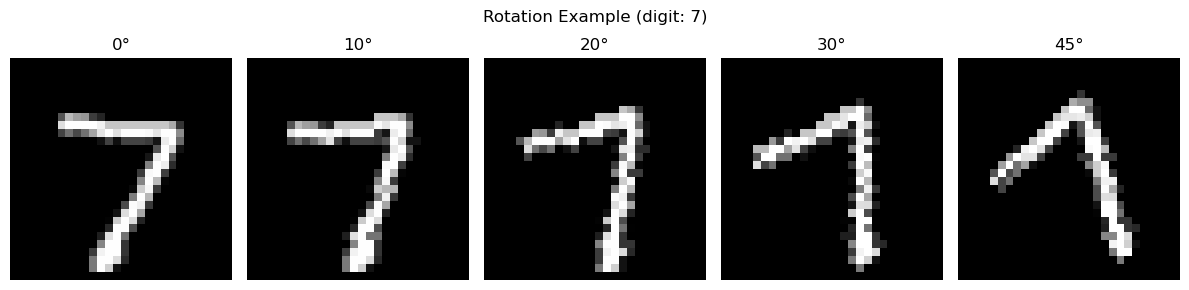

In [7]:
def perturb_rotation(images, angle_degrees):
    """Rotate each image by a fixed angle (in degrees)."""
    rotated = torch.zeros_like(images)
    for i in range(len(images)):
        img_pil = TF.to_pil_image(images[i].unsqueeze(0))  # [1, 28, 28]
        img_pil = TF.rotate(img_pil, angle_degrees, fill=0)
        rotated[i] = TF.to_tensor(img_pil).squeeze(0)
    return rotated


# TODO: Add more perturbation functions. Here are some starters:

def perturb_translation(images, shift_pixels):
    """Shift images by shift_pixels in x and y direction."""
    shifted = torch.zeros_like(images)
    for i in range(len(images)):
        img_pil = TF.to_pil_image(images[i].unsqueeze(0))  # [1, 28, 28]
        img_pil = TF.affine(img_pil, angle=0, translate=shift_pixels, scale=1.0, shear=0, fill=0)
        shifted[i] = TF.to_tensor(img_pil).squeeze(0)
    return shifted

def perturb_noise(images, noise_std):
    """Add Gaussian noise with given standard deviation."""
    noise = torch.randn_like(images) * noise_std
    noisy_images = images + noise
    return torch.clamp(noisy_images, 0.0, 1.0)

def perturb_blur(images, sigma):
    """Apply Gaussian blur with given sigma."""
    blurred = torch.zeros_like(images)
    for i in range(len(images)):
        img_np = images[i].numpy()
        img_blurred = scipy.ndimage.gaussian_filter(img_np, sigma=sigma)
        blurred[i] = torch.from_numpy(img_blurred)
    return blurred

def perturb_erosion(images, iterations):
    """Thin the strokes by morphological erosion."""
    eroded = torch.zeros_like(images)
    for i in range(len(images)):
        img_np = images[i].numpy()
        img_eroded = scipy.ndimage.binary_erosion(img_np > 0.5, iterations=iterations).astype(float)
        eroded[i] = torch.from_numpy(img_eroded)
    return eroded

def perturb_inversion(images):
    """Invert colors: white digit on black -> black digit on white."""
    return 1.0 - images

# Be creative! You can also combine perturbations.


# Quick visual check: show rotation example
angles = [0, 10, 20, 30, 45]
fig, axes = plt.subplots(1, len(angles), figsize=(12, 3))
sample_img = test_images[:1]  # Take first test image
for ax, angle in zip(axes, angles):
    if angle == 0:
        ax.imshow(sample_img[0], cmap='gray')
    else:
        ax.imshow(perturb_rotation(sample_img, angle)[0], cmap='gray')
    ax.set_title(f'{angle}°')
    ax.axis('off')
plt.suptitle(f'Rotation Example (digit: {test_labels[0].item()})')
plt.tight_layout()
plt.show()

## 7. Evaluating Models on Perturbed Data

Helper function to evaluate a trained model on a perturbed test set.  
Perturbed images (in `[0, 1]` range) are normalized to match the training distribution before evaluation.

In [8]:
def evaluate_on_perturbed(model, perturbed_images, labels, batch_size=128):
    """Evaluate a trained model on perturbed images.

    Args:
        model: Trained model (MLP or CNN).
        perturbed_images: Tensor [N, 28, 28], values in [0, 1].
        labels: Tensor [N] of true labels.
        batch_size: Batch size for evaluation.

    Returns:
        accuracy: Overall accuracy (%).
        per_class_acc: Dict mapping class -> accuracy (%).
        all_preds: Array of predictions.
        all_labels: Array of true labels.
    """
    # Normalize to match training distribution
    normalized = (perturbed_images - MNIST_MEAN) / MNIST_STD
    normalized = normalized.unsqueeze(1)  # [N, 1, 28, 28]

    dataset = TensorDataset(normalized, labels)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    model.eval()
    all_preds, all_labels_list = [], []
    correct, total = 0, 0

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs = model(imgs)
            _, predicted = outputs.max(1)
            correct += predicted.eq(lbls).sum().item()
            total += lbls.size(0)
            all_preds.extend(predicted.cpu().numpy())
            all_labels_list.extend(lbls.cpu().numpy())

    accuracy = 100.0 * correct / total
    all_preds = np.array(all_preds)
    all_labels_arr = np.array(all_labels_list)

    # Per-class accuracy
    per_class_acc = {}
    for c in range(10):
        mask = all_labels_arr == c
        if mask.sum() > 0:
            per_class_acc[c] = 100.0 * (all_preds[mask] == c).sum() / mask.sum()

    return accuracy, per_class_acc, all_preds, all_labels_arr

## 8. Plotting Functions

Ready-to-use visualizations for comparing MLP vs. CNN robustness.

In [9]:
def plot_degradation_curve(intensities, mlp_accs, cnn_accs, xlabel, title):
    """Plot accuracy vs. perturbation intensity for MLP and CNN."""
    plt.figure(figsize=(8, 5))
    plt.plot(intensities, mlp_accs, 'o-', label='MLP', linewidth=2, markersize=8)
    plt.plot(intensities, cnn_accs, 's-', label='CNN', linewidth=2, markersize=8)
    plt.xlabel(xlabel)
    plt.ylabel('Accuracy (%)')
    plt.title(title)
    plt.legend()
    plt.ylim(0, 105)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(true_labels, predictions, title='Confusion Matrix'):
    """Plot a confusion matrix."""
    cm = confusion_matrix(true_labels, predictions, labels=range(10))
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_per_class_comparison(mlp_per_class, cnn_per_class, title='Per-Class Accuracy'):
    """Side-by-side bar chart of per-class accuracy for MLP and CNN."""
    classes = list(range(10))
    mlp_vals = [mlp_per_class.get(c, 0) for c in classes]
    cnn_vals = [cnn_per_class.get(c, 0) for c in classes]

    x = np.arange(10)
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width/2, mlp_vals, width, label='MLP', color='steelblue')
    ax.bar(x + width/2, cnn_vals, width, label='CNN', color='darkorange')
    ax.set_xlabel('Digit Class')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.legend()
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()


def show_failure_examples(images, true_labels, predictions, model_name,
                          n_examples=10, title=None):
    """Show examples where the model made wrong predictions."""
    wrong = np.where(predictions != true_labels)[0]
    if len(wrong) == 0:
        print(f'{model_name}: No errors found!')
        return
    indices = wrong[:n_examples]
    fig, axes = plt.subplots(1, len(indices), figsize=(2 * len(indices), 3))
    if len(indices) == 1:
        axes = [axes]
    for ax, idx in zip(axes, indices):
        ax.imshow(images[idx], cmap='gray')
        ax.set_title(f'True: {true_labels[idx]}\nPred: {predictions[idx]}',
                     color='red', fontsize=10)
        ax.axis('off')
    plt.suptitle(title or f'{model_name} -- Failure Examples', fontsize=12)
    plt.tight_layout()
    plt.show()

## 9. Results Collection

Use this DataFrame to systematically collect all experiment results.

In [10]:
results = pd.DataFrame(columns=[
    'perturbation',      # e.g. 'rotation', 'noise', 'shift'
    'intensity',       # e.g. 15 (degrees), 0.3 (noise std), 3 (pixels)
    'mlp_accuracy',    # MLP accuracy on perturbed set
    'cnn_accuracy',    # CNN accuracy on perturbed set
    'accuracy_diff',   # CNN - MLP (positive = CNN better)
])

# Add baseline (clean test set) as first row
results.loc[len(results)] = ['clean', 0, mlp_test_acc, cnn_test_acc,
                              cnn_test_acc - mlp_test_acc]
print(results.to_string(index=False))

perturbation  intensity  mlp_accuracy  cnn_accuracy  accuracy_diff
       clean          0         98.03         99.11           1.08


---

## 10. Experiment 1: Rotation

This experiment is provided as a **complete example** to show the workflow.  
For your own perturbation types, follow the same pattern.

Evaluating rotation = 5°...
  MLP: 97.42%  |  CNN: 98.78%
Evaluating rotation = 10°...
  MLP: 96.27%  |  CNN: 98.31%
Evaluating rotation = 15°...
  MLP: 94.59%  |  CNN: 97.55%
Evaluating rotation = 20°...
  MLP: 90.70%  |  CNN: 95.50%
Evaluating rotation = 30°...
  MLP: 77.60%  |  CNN: 85.96%
Evaluating rotation = 45°...
  MLP: 49.77%  |  CNN: 60.90%


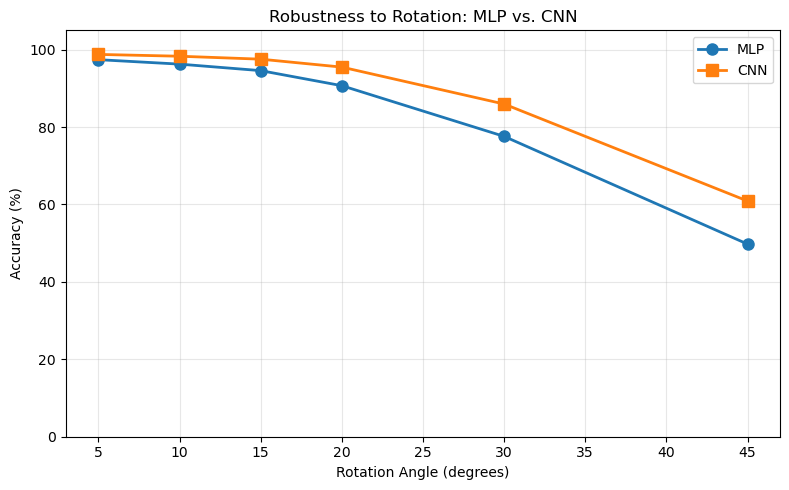

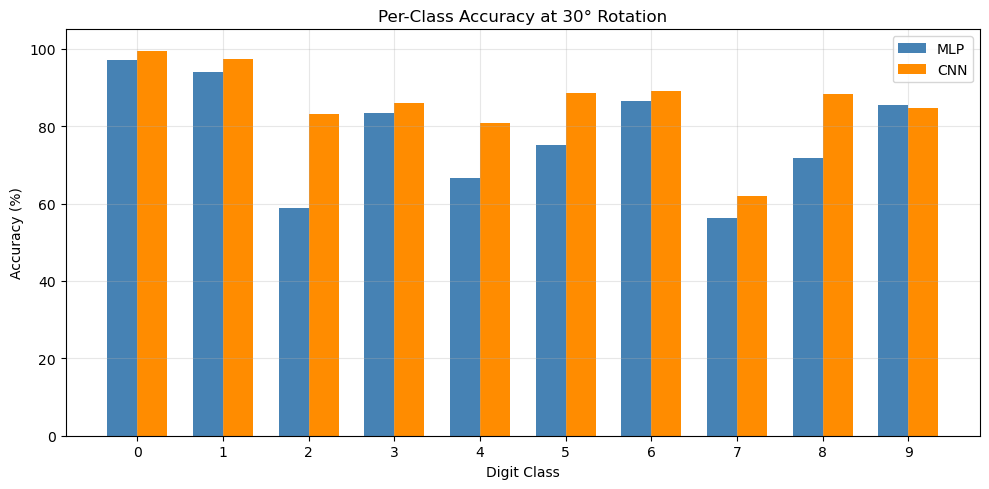

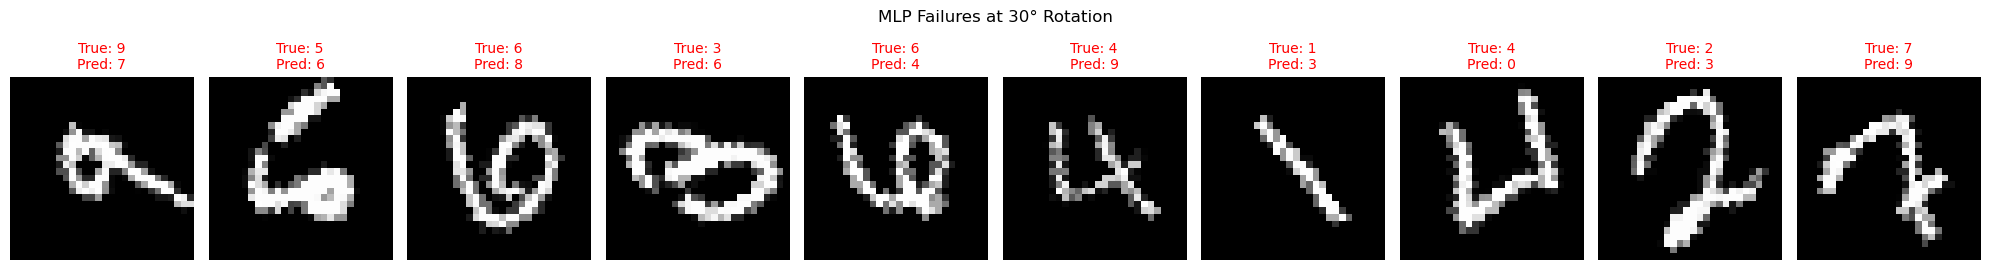

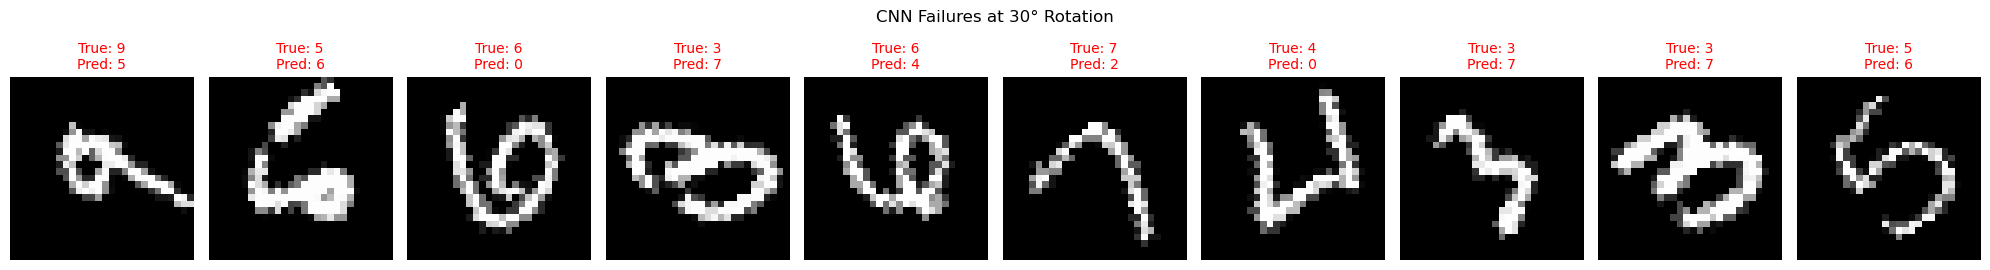

In [11]:
# Example experiment: Rotation at multiple angles
rotation_angles = [5, 10, 15, 20, 30, 45]
mlp_rot_accs, cnn_rot_accs = [], []

for angle in rotation_angles:
    print(f'Evaluating rotation = {angle}°...')
    perturbed = perturb_rotation(test_images, angle)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)

    mlp_rot_accs.append(mlp_acc)
    cnn_rot_accs.append(cnn_acc)

    results.loc[len(results)] = ['rotation', angle, mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

# Plot degradation curve
plot_degradation_curve(rotation_angles, mlp_rot_accs, cnn_rot_accs,
                       xlabel='Rotation Angle (degrees)',
                       title='Robustness to Rotation: MLP vs. CNN')

# Show per-class accuracy at 30° rotation
perturbed_30 = perturb_rotation(test_images, 30)
_, mlp_pc_30, mlp_pr_30, mlp_tr_30 = evaluate_on_perturbed(mlp_model, perturbed_30, test_labels)
_, cnn_pc_30, cnn_pr_30, cnn_tr_30 = evaluate_on_perturbed(cnn_model, perturbed_30, test_labels)
plot_per_class_comparison(mlp_pc_30, cnn_pc_30, title='Per-Class Accuracy at 30° Rotation')

# Show some failure examples
show_failure_examples(perturbed_30.numpy(), mlp_tr_30, mlp_pr_30, 'MLP',
                      title='MLP Failures at 30° Rotation')
show_failure_examples(perturbed_30.numpy(), cnn_tr_30, cnn_pr_30, 'CNN',
                      title='CNN Failures at 30° Rotation')

---

## 11. Experiment 2: Translation

TODO: Choose your second perturbation type. Follow the same pattern as the rotation experiment above.

Evaluating translation = (1, 1) pixels...
  MLP: 91.21%  |  CNN: 98.22%
Evaluating translation = (2, 2) pixels...
  MLP: 56.89%  |  CNN: 92.49%
Evaluating translation = (3, 3) pixels...
  MLP: 21.27%  |  CNN: 72.22%
Evaluating translation = (4, 4) pixels...
  MLP: 6.16%  |  CNN: 39.17%
Evaluating translation = (5, 5) pixels...
  MLP: 3.25%  |  CNN: 12.81%


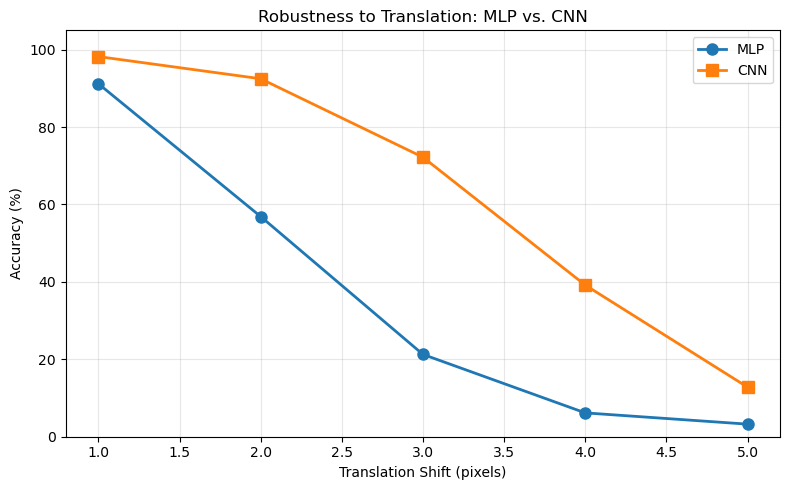

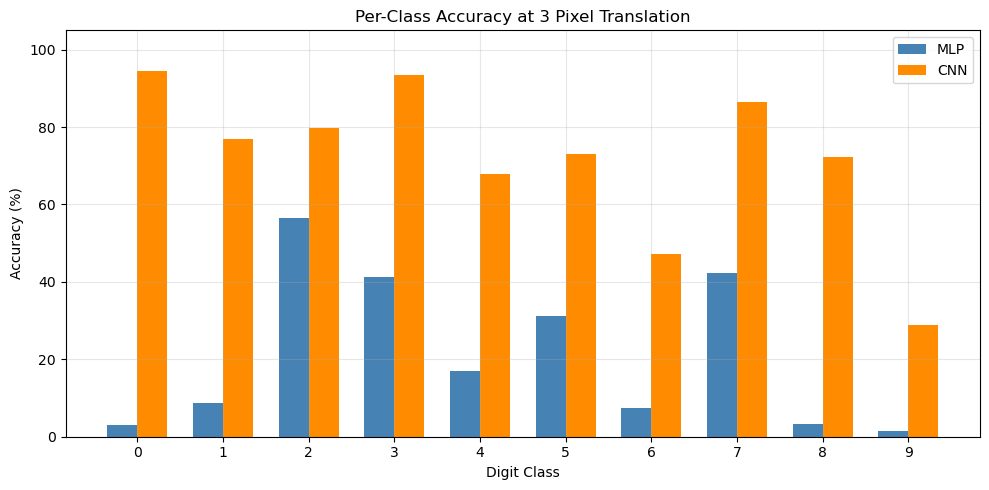

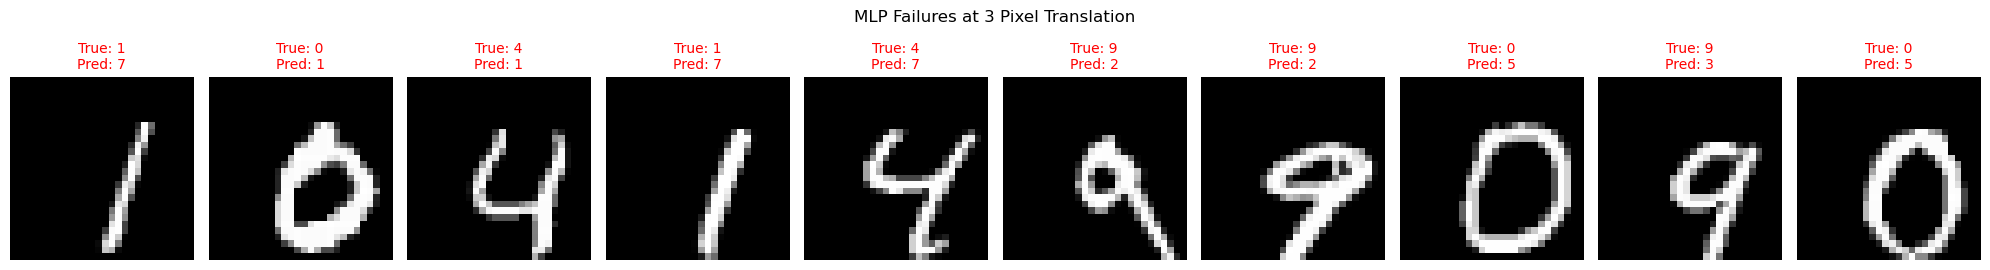

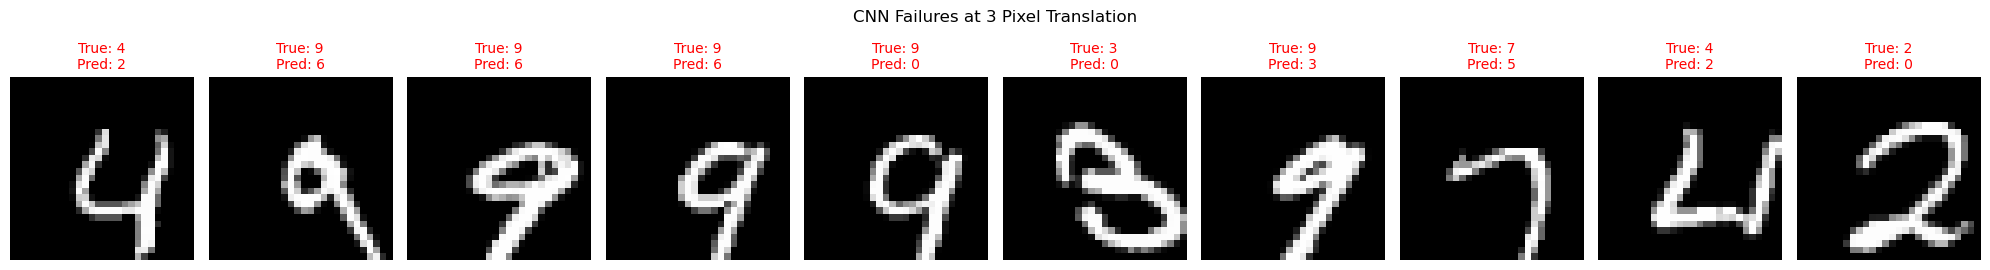

In [12]:
# TODO: Implement your second perturbation type.
# Follow the rotation experiment pattern:
#   1. Define intensity levels
#   2. Loop over intensities, evaluate both models
#   3. Append results to the results DataFrame
#   4. Plot degradation curve
#   5. Show per-class accuracy and failure examples for an interesting intensity

translation = [(1, 1), (2, 2), (3, 3), (4, 4), (5, 5)]
mlp_trans_accs, cnn_trans_accs = [], []

for shift in translation:
    print(f'Evaluating translation = {shift} pixels...')
    perturbed = perturb_translation(test_images, shift)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)  

    mlp_trans_accs.append(mlp_acc)
    cnn_trans_accs.append(cnn_acc)

    results.loc[len(results)] = ['translation', shift[0], mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

plot_degradation_curve([s[0] for s in translation], mlp_trans_accs, cnn_trans_accs,
                       xlabel='Translation Shift (pixels)',
                       title='Robustness to Translation: MLP vs. CNN')  

translation_3 = perturb_translation(test_images, (3, 3))
_, mlp_pc_3, mlp_pr_3, mlp_tr_3 = evaluate_on_perturbed(mlp_model, translation_3, test_labels)
_, cnn_pc_3, cnn_pr_3, cnn_tr_3 = evaluate_on_perturbed(cnn_model, translation_3, test_labels)
plot_per_class_comparison(mlp_pc_3, cnn_pc_3, title='Per-Class Accuracy at 3 Pixel Translation')

show_failure_examples(translation_3.numpy(), mlp_tr_3, mlp_pr_3, 'MLP',
                      title='MLP Failures at 3 Pixel Translation')
show_failure_examples(translation_3.numpy(), cnn_tr_3, cnn_pr_3, 'CNN',
                      title='CNN Failures at 3 Pixel Translation')

---

## 12. Experiment 3: Noise

TODO: Choose your third perturbation type.

Evaluating noise = 0.1...
  MLP: 98.00%  |  CNN: 99.02%
Evaluating noise = 0.2...
  MLP: 97.27%  |  CNN: 98.51%
Evaluating noise = 0.3...
  MLP: 94.31%  |  CNN: 96.42%
Evaluating noise = 0.4...
  MLP: 86.65%  |  CNN: 87.30%
Evaluating noise = 0.5...
  MLP: 75.24%  |  CNN: 70.95%


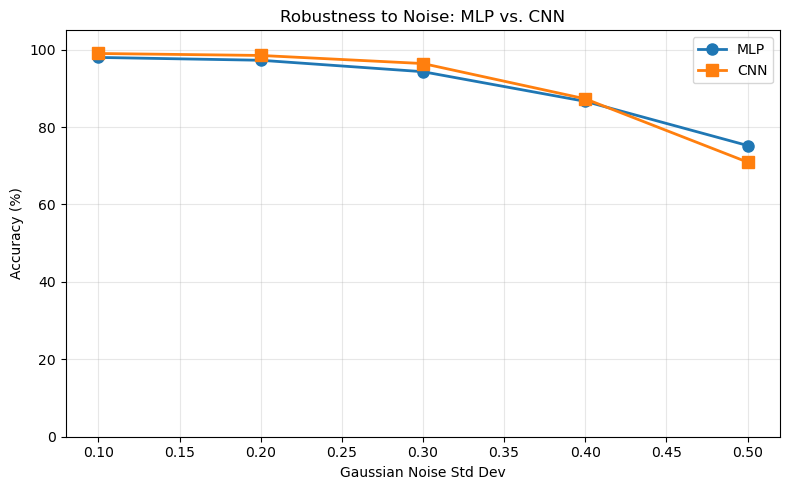

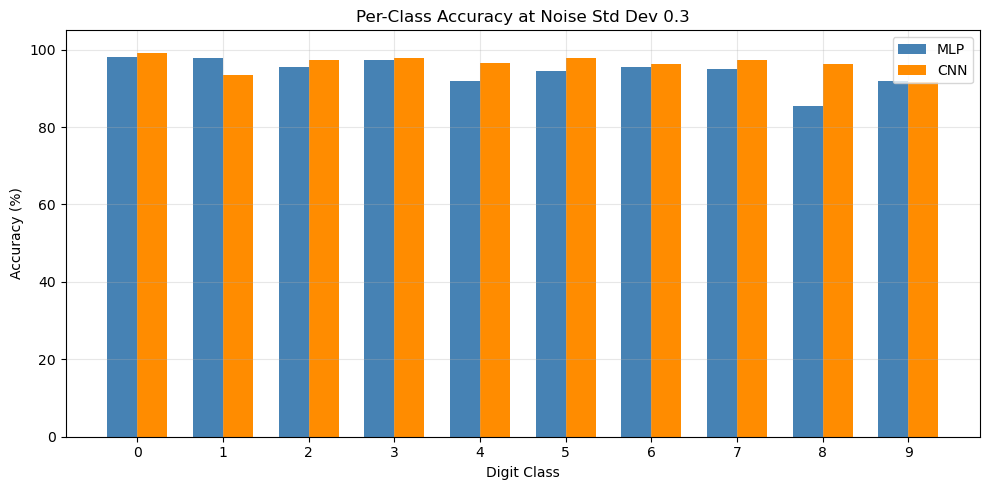

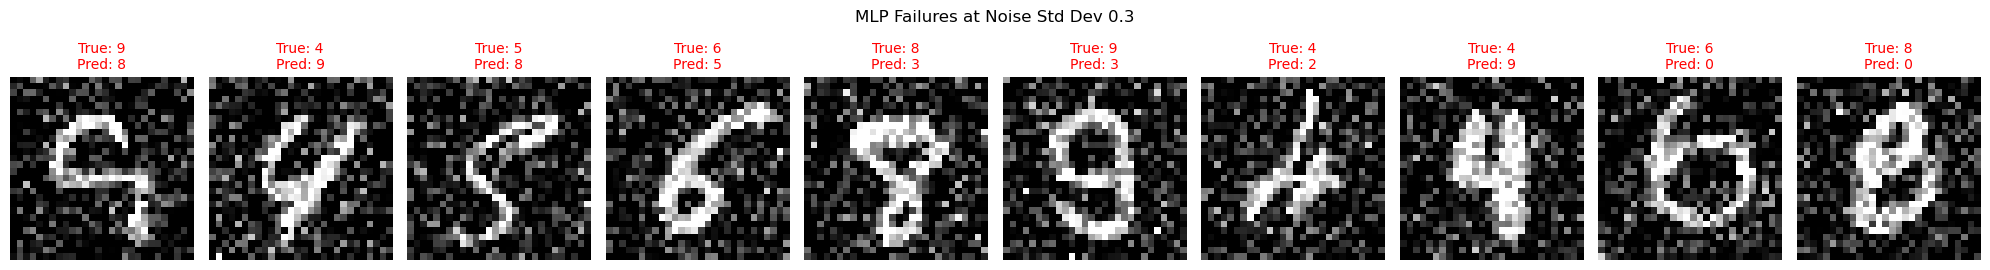

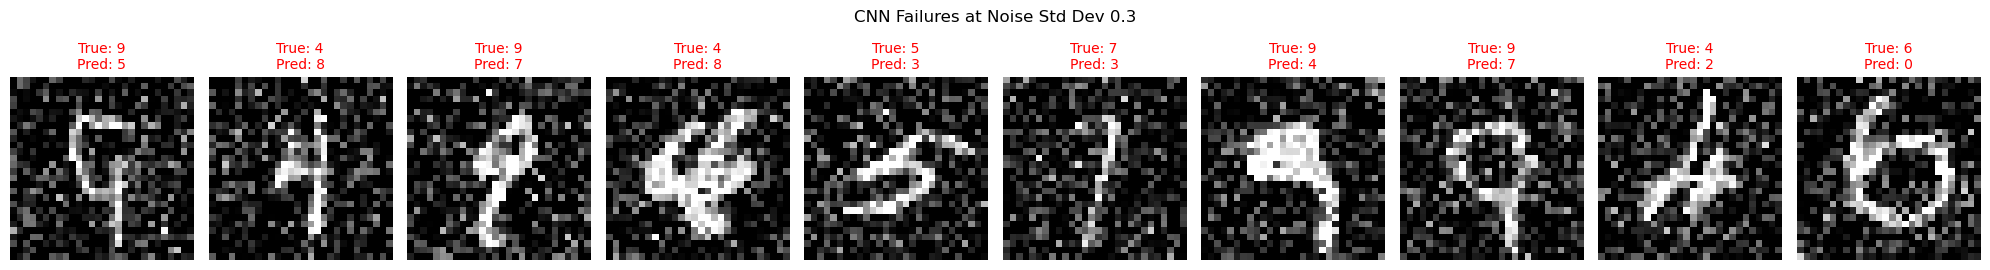

In [19]:
# TODO: Implement your third perturbation type.

noise=[0.1, 0.2, 0.3, 0.4, 0.5]
mlp_noise_accs, cnn_noise_accs = [], []

for noise_std in noise:
    print(f'Evaluating noise = {noise_std}...')
    perturbed = perturb_noise(test_images, noise_std)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)  

    mlp_noise_accs.append(mlp_acc)
    cnn_noise_accs.append(cnn_acc)

    results.loc[len(results)] = ['noise', noise_std, mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

plot_degradation_curve(noise, mlp_noise_accs, cnn_noise_accs,
                       xlabel='Gaussian Noise Std Dev',
                       title='Robustness to Noise: MLP vs. CNN')

noise_0_3 = perturb_noise(test_images, 0.3)
_, mlp_pc_0_3, mlp_pr_0_3, mlp_tr_0_3 = evaluate_on_perturbed(mlp_model, noise_0_3, test_labels)
_, cnn_pc_0_3, cnn_pr_0_3, cnn_tr_0_3 = evaluate_on_perturbed(cnn_model, noise_0_3, test_labels)
plot_per_class_comparison(mlp_pc_0_3, cnn_pc_0_3, title='Per-Class Accuracy at Noise Std Dev 0.3')

show_failure_examples(noise_0_3.numpy(), mlp_tr_0_3, mlp_pr_0_3, 'MLP',
                      title='MLP Failures at Noise Std Dev 0.3')
show_failure_examples(noise_0_3.numpy(), cnn_tr_0_3, cnn_pr_0_3, 'CNN',
                      title='CNN Failures at Noise Std Dev 0.3')

---

## 13. Experiment 4: Blur

TODO: Choose your fourth perturbation type. Remember: at least one should be creative/hand-drawn!

Evaluating blur = 0.5...
  MLP: 98.08%  |  CNN: 99.06%
Evaluating blur = 1.0...
  MLP: 97.42%  |  CNN: 98.77%
Evaluating blur = 1.5...
  MLP: 92.16%  |  CNN: 96.99%
Evaluating blur = 2.0...
  MLP: 76.20%  |  CNN: 91.91%
Evaluating blur = 3.0...
  MLP: 41.36%  |  CNN: 56.70%


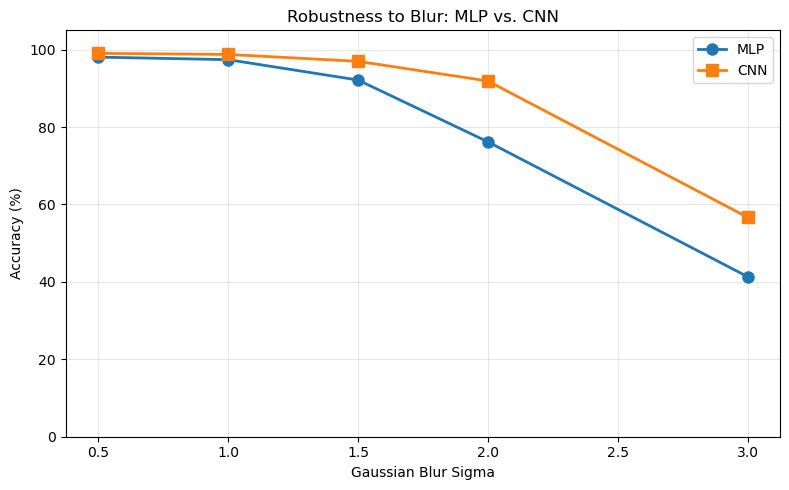

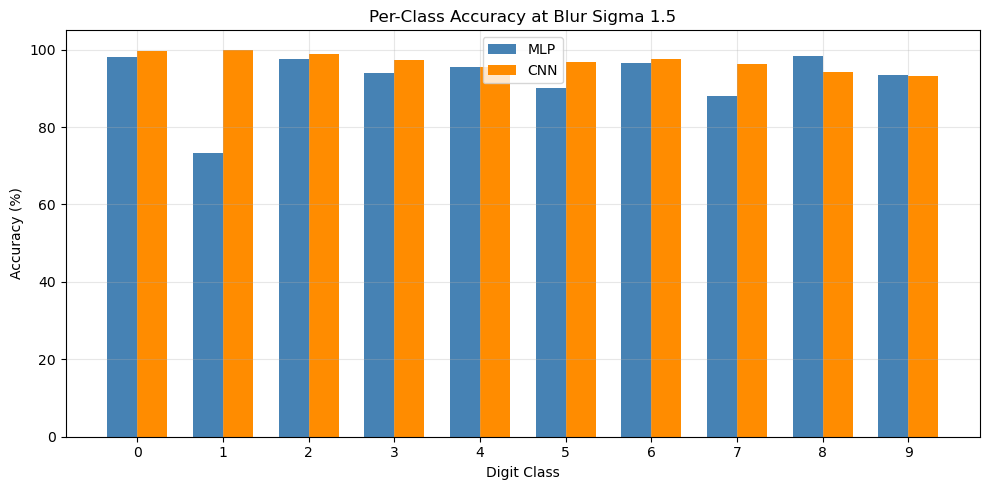

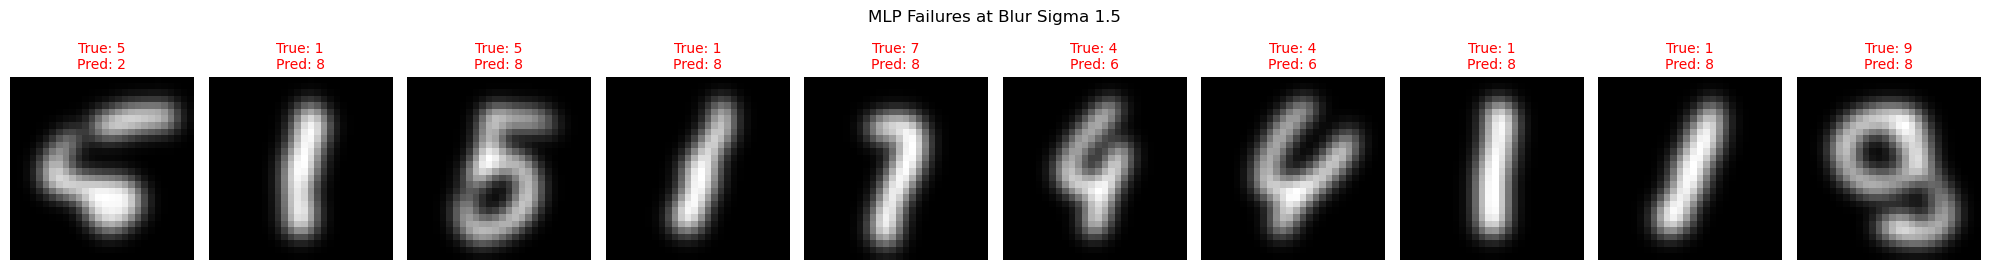

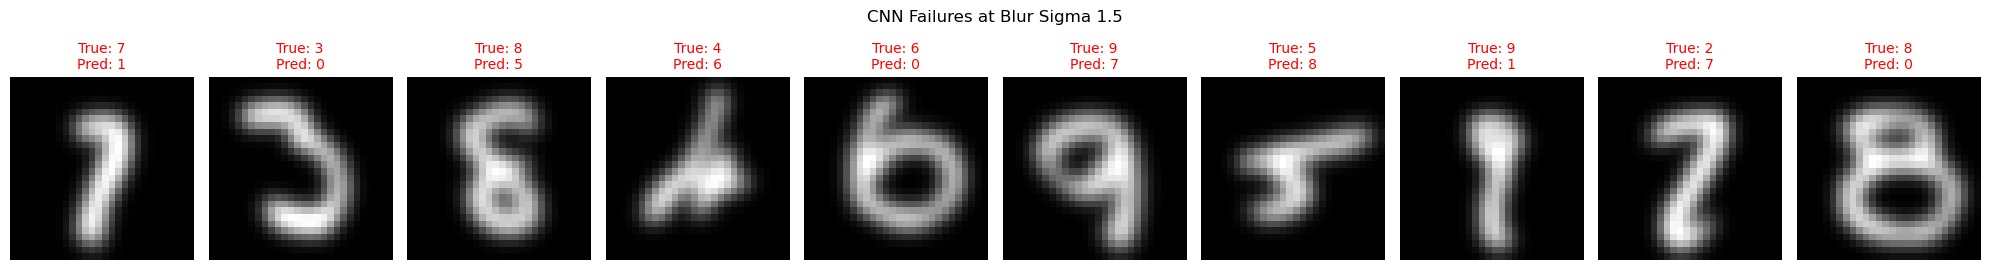

In [20]:
blur = [0.5, 1.0, 1.5, 2.0, 3.0]
mlp_blur_accs, cnn_blur_accs = [], []

for sigma in blur:
    print(f'Evaluating blur = {sigma}...')
    perturbed = perturb_blur(test_images, sigma)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)  

    mlp_blur_accs.append(mlp_acc)
    cnn_blur_accs.append(cnn_acc)

    results.loc[len(results)] = ['blur', sigma, mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

plot_degradation_curve(blur, mlp_blur_accs, cnn_blur_accs,
                       xlabel='Gaussian Blur Sigma',
                          title='Robustness to Blur: MLP vs. CNN') 

blur_1_5 = perturb_blur(test_images, 1.5)
_, mlp_pc_1_5, mlp_pr_1_5, mlp_tr_1_5 = evaluate_on_perturbed(mlp_model, blur_1_5, test_labels)
_, cnn_pc_1_5, cnn_pr_1_5, cnn_tr_1_5 = evaluate_on_perturbed(cnn_model, blur_1_5, test_labels)
plot_per_class_comparison(mlp_pc_1_5, cnn_pc_1_5, title='Per-Class Accuracy at Blur Sigma 1.5')

show_failure_examples(blur_1_5.numpy(), mlp_tr_1_5, mlp_pr_1_5, 'MLP',
                      title='MLP Failures at Blur Sigma 1.5')   
show_failure_examples(blur_1_5.numpy(), cnn_tr_1_5, cnn_pr_1_5, 'CNN',
                      title='CNN Failures at Blur Sigma 1.5')

---

## 14. Experiment 5: Erosion

Evaluating erosion = 1 iterations...
  MLP: 59.49%  |  CNN: 66.69%
Evaluating erosion = 2 iterations...
  MLP: 13.91%  |  CNN: 18.43%
Evaluating erosion = 3 iterations...
  MLP: 9.25%  |  CNN: 12.40%
Evaluating erosion = 4 iterations...
  MLP: 8.92%  |  CNN: 11.59%
Evaluating erosion = 5 iterations...
  MLP: 8.92%  |  CNN: 11.38%


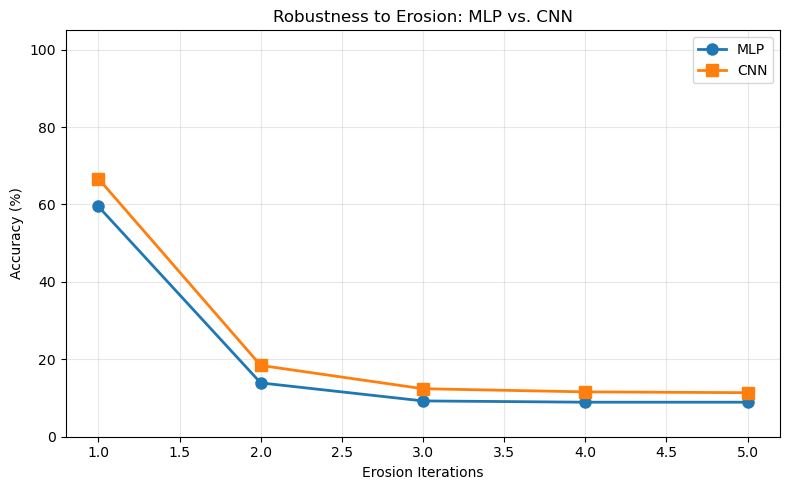

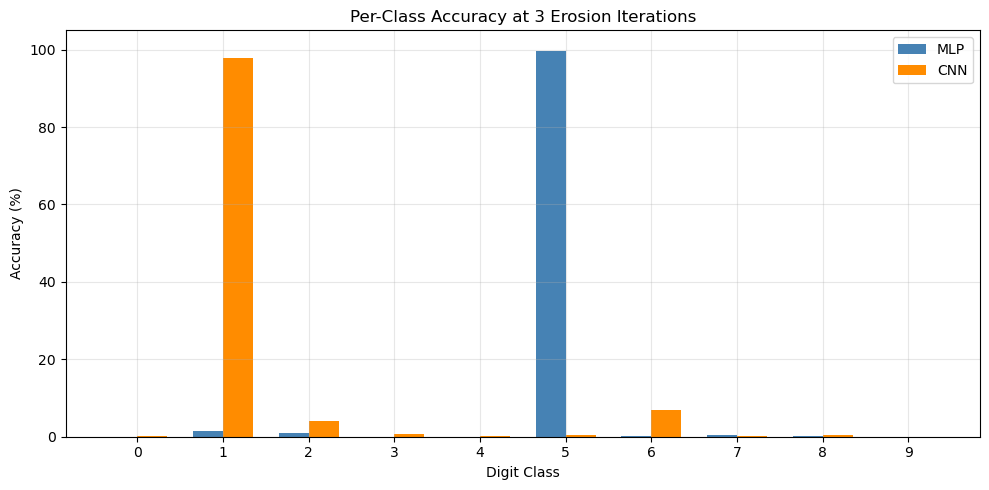

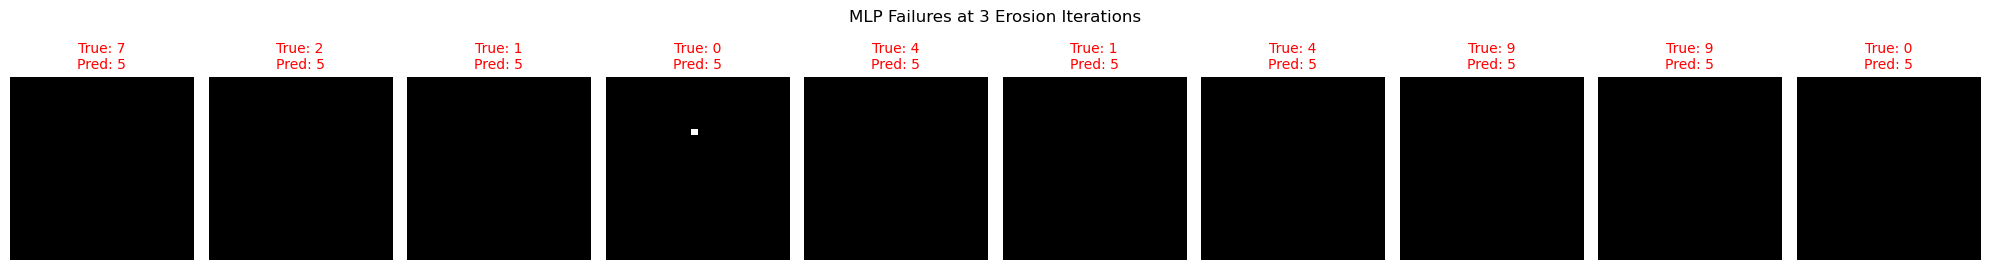

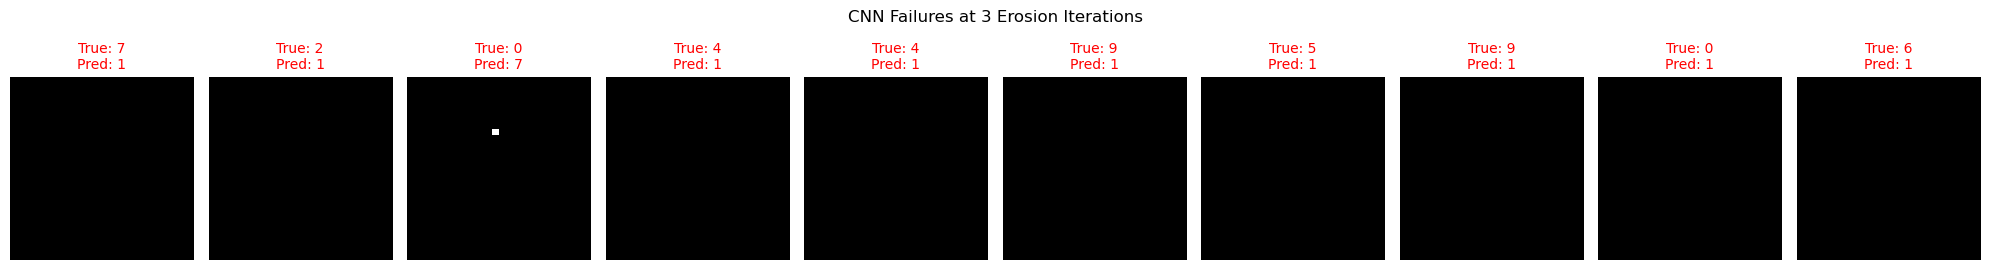

In [22]:
erosion = [1, 2, 3, 4, 5]
mlp_erosion_accs, cnn_erosion_accs = [], []

for iter in erosion:
    print(f'Evaluating erosion = {iter} iterations...')
    perturbed = perturb_erosion(test_images, iter)

    mlp_acc, mlp_pc, mlp_pr, mlp_tr = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
    cnn_acc, cnn_pc, cnn_pr, cnn_tr = evaluate_on_perturbed(cnn_model, perturbed, test_labels)  

    mlp_erosion_accs.append(mlp_acc)
    cnn_erosion_accs.append(cnn_acc)

    results.loc[len(results)] = ['erosion', iter, mlp_acc, cnn_acc, cnn_acc - mlp_acc]
    print(f'  MLP: {mlp_acc:.2f}%  |  CNN: {cnn_acc:.2f}%')

plot_degradation_curve(erosion, mlp_erosion_accs, cnn_erosion_accs,
                       xlabel='Erosion Iterations',
                       title='Robustness to Erosion: MLP vs. CNN') 
erosion_3 = perturb_erosion(test_images, 3)
_, mlp_pc_3e, mlp_pr_3e, mlp_tr_3e = evaluate_on_perturbed(mlp_model, erosion_3, test_labels)
_, cnn_pc_3e, cnn_pr_3e, cnn_tr_3e = evaluate_on_perturbed(cnn_model, erosion_3, test_labels)
plot_per_class_comparison(mlp_pc_3e, cnn_pc_3e, title='Per-Class Accuracy at 3 Erosion Iterations')
show_failure_examples(erosion_3.numpy(), mlp_tr_3e, mlp_pr_3e, 'MLP',
                      title='MLP Failures at 3 Erosion Iterations')

show_failure_examples(erosion_3.numpy(), cnn_tr_3e, cnn_pr_3e, 'CNN',
                      title='CNN Failures at 3 Erosion Iterations')
inversion = perturb_inversion(test_images)
mlp_acc_inv, mlp_pc_inv, mlp_pr_inv, mlp_tr_inv = evaluate_on_perturbed(mlp_model, inversion, test_labels)
cnn_acc_inv, cnn_pc_inv, cnn_pr_inv, cnn_tr_inv = evaluate_on_perturbed(cnn_model, inversion, test_labels)
results.loc[len(results)] = ['inversion', 0, mlp_acc_inv, cnn_acc_inv, cnn_acc_inv - mlp_acc_inv]   

---

## 15. Experiment 6: Inversion

  MLP: 1.23%  |  CNN: 31.05%
  MLP: 1.23%  |  CNN: 31.05%


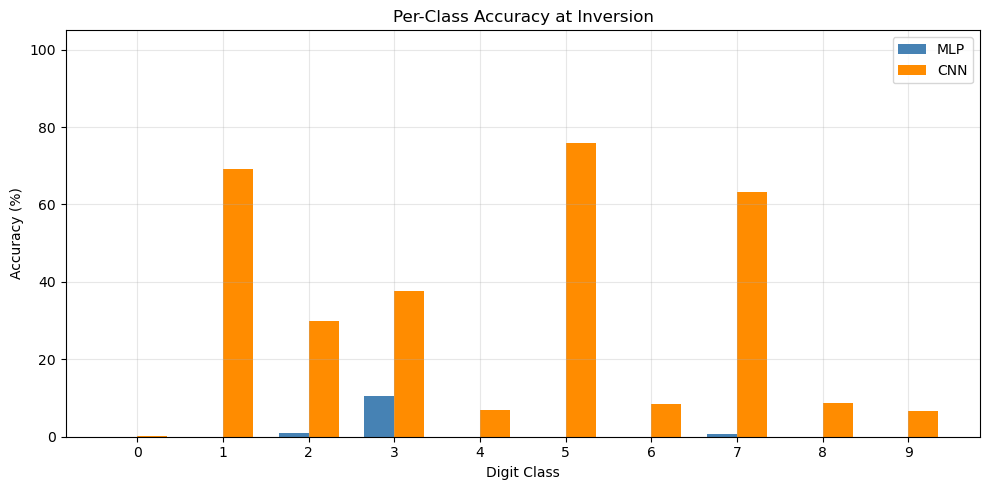

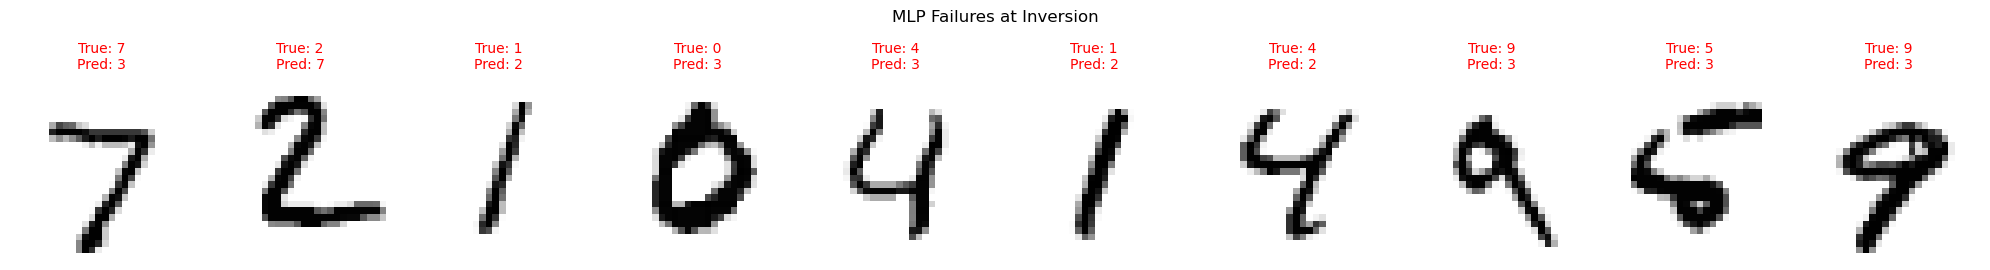

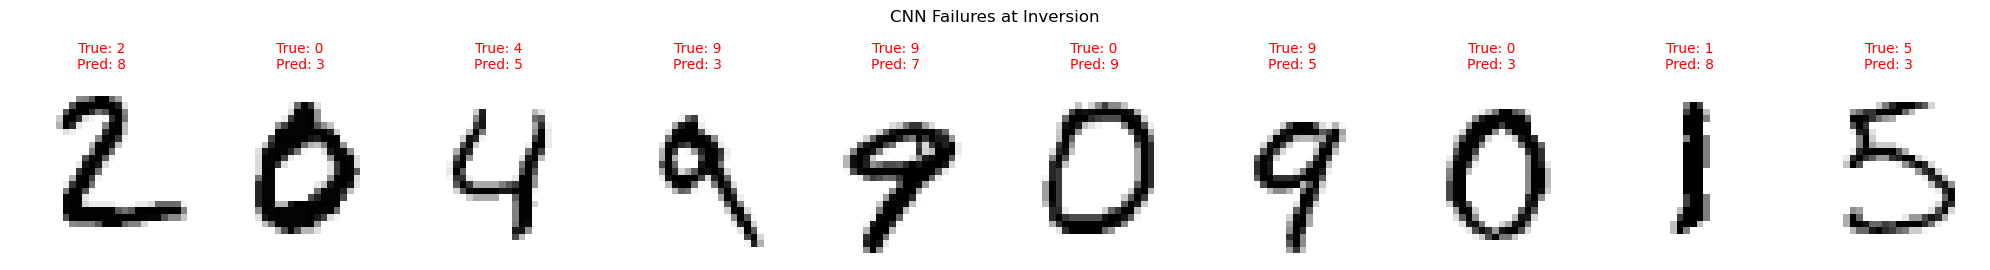

In [26]:
print(f'  MLP: {mlp_acc_inv:.2f}%  |  CNN: {cnn_acc_inv:.2f}%')

perturbed = perturb_inversion(test_images)

mlp_acc_inv, mlp_pc_inv, mlp_pr_inv, mlp_tr_inv = evaluate_on_perturbed(mlp_model, perturbed, test_labels)
cnn_acc_inv, cnn_pc_inv, cnn_pr_inv, cnn_tr_inv = evaluate_on_perturbed(cnn_model, perturbed, test_labels)

results.loc[len(results)] = ['inversion', 0, mlp_acc_inv, cnn_acc_inv, cnn_acc_inv - mlp_acc_inv]
print(f'  MLP: {mlp_acc_inv:.2f}%  |  CNN: {cnn_acc_inv:.2f}%')

plot_per_class_comparison(mlp_pc_inv, cnn_pc_inv, title='Per-Class Accuracy at Inversion')
show_failure_examples(inversion.numpy(), mlp_tr_inv, mlp_pr_inv, 'MLP',
                      title='MLP Failures at Inversion')    
show_failure_examples(inversion.numpy(), cnn_tr_inv, cnn_pr_inv, 'CNN',
                      title='CNN Failures at Inversion')    

---

## 16. Experiment 7 : Hand drawn images

Loaded 10 hand-drawn images.
Hand-drawn MLP Accuracy: 10.00%
Hand-drawn CNN Accuracy: 10.00%


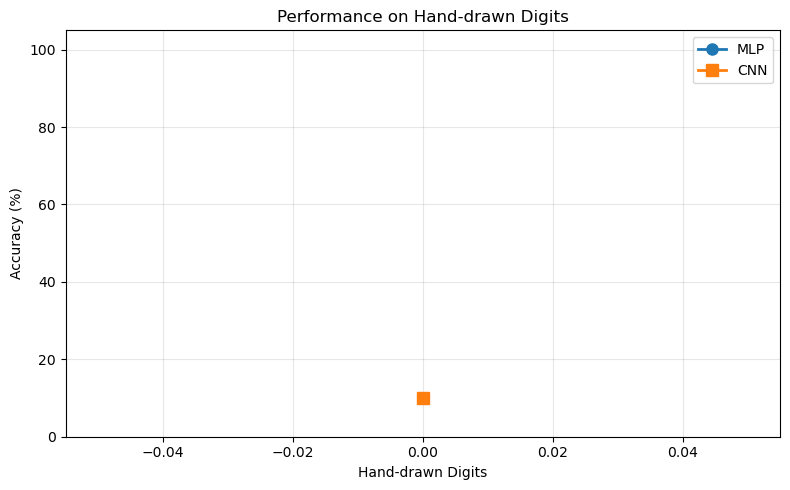

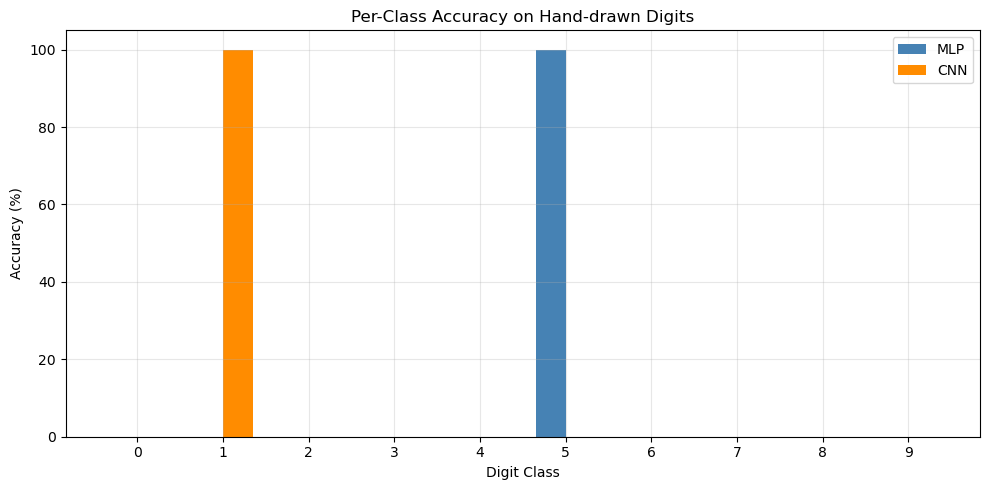

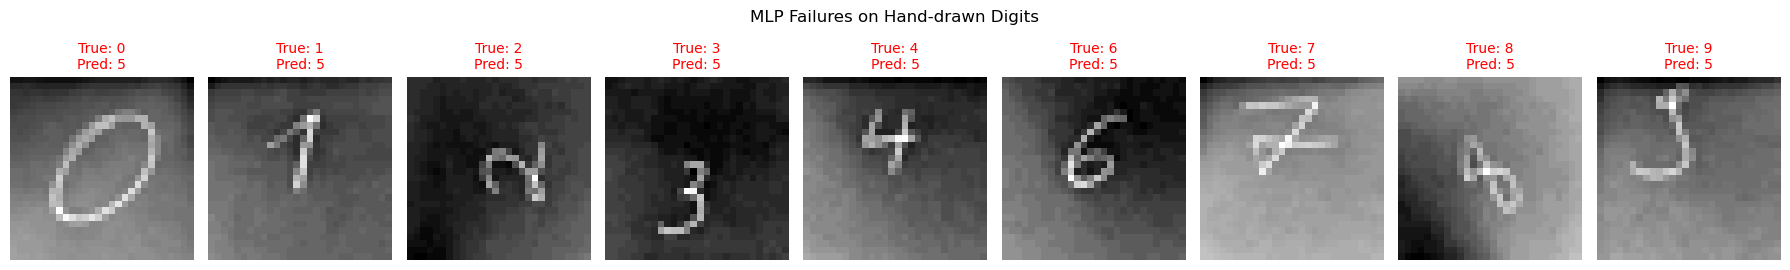

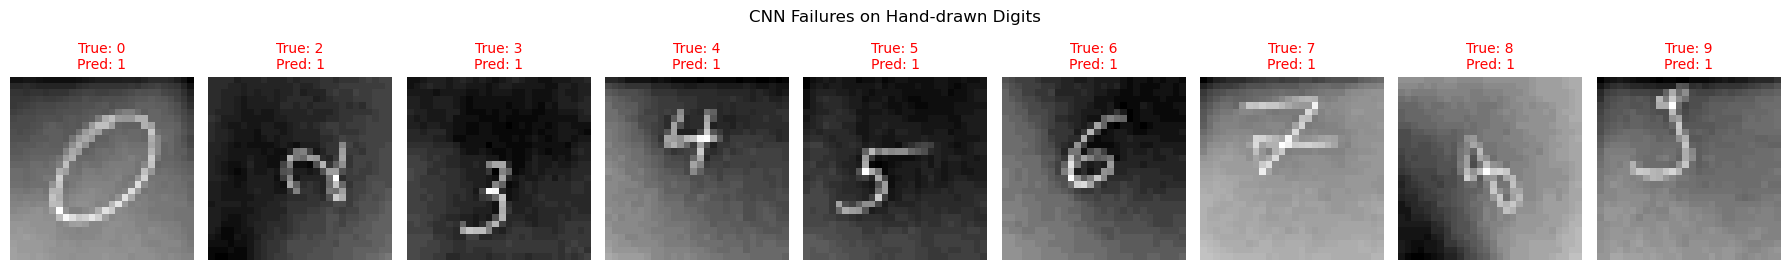

In [35]:
# TODO: Implement your fourth perturbation type.
# If this is your hand-drawn/creative experiment, you might:
#   - Load hand-drawn images from a folder
#   - Resize to 28x28, convert to grayscale
#   - Normalize to [0, 1] range (white digit on black background, like MNIST)
#
# Example for loading hand-drawn images:
#
# def load_handdrawn_images(folder_path):
#     """Load hand-drawn digit images from a folder.
#     Expected: files named like '0_a.png', '3_b.png' (digit_id.ext)"""
#     images, labels = [], []
#     for fname in sorted(os.listdir(folder_path)):
#         if not fname.endswith(('.png', '.jpg')):
#             continue
#         label = int(fname.split('_')[0])  # digit class from filename
#         img = Image.open(os.path.join(folder_path, fname)).convert('L')
#         img = img.resize((28, 28))
#         img_arr = np.array(img, dtype=np.float32) / 255.0
#         # MNIST: white digit on black background
#         # If your image is dark digit on white background, invert:
#         # img_arr = 1.0 - img_arr
#         images.append(img_arr)
#         labels.append(label)
#     return torch.tensor(np.stack(images)), torch.tensor(labels)

def load_handdrawn_images(hand_drawn_numbers):
    """Load hand-drawn digit images from a folder.
    Expected: files named like '0_a.png', '3_b.png' (digit_id.ext)"""
    images, labels = [], []
    for fname in sorted(os.listdir(hand_drawn_numbers)):
        if not fname.endswith(('.png', '.jpg')):
            continue
        label = int(fname.split('_')[0])  # digit class from filename
        img = Image.open(os.path.join(hand_drawn_numbers, fname)).convert('L')
        img = img.resize((28, 28))
        img = perturb_inversion(TF.to_tensor(img)).squeeze(0)
        img_arr = np.array(img, dtype=np.float32) / 255.0
        # MNIST: white digit on black background
        # If your image is dark digit on white background, invert:
        # img_arr = 1.0 - img_arr
        images.append(img_arr)
        labels.append(label)
    return torch.tensor(np.stack(images)), torch.tensor(labels)

hand_drawn_numbers = 'hand_drawn_numbers'
hand_images, hand_labels = load_handdrawn_images(hand_drawn_numbers)
print(f'Loaded {len(hand_images)} hand-drawn images.')

mlp_acc_hand, mlp_pc_hand, mlp_pr_hand, mlp_tr_hand = evaluate_on_perturbed(mlp_model, hand_images, hand_labels)
cnn_acc_hand, cnn_pc_hand, cnn_pr_hand, cnn_tr_hand = evaluate_on_perturbed(cnn_model, hand_images, hand_labels)

results.loc[len(results)] = ['hand-drawn', 0, mlp_acc_hand, cnn_acc_hand, cnn_acc_hand - mlp_acc_hand]
print(f'Hand-drawn MLP Accuracy: {mlp_acc_hand:.2f}%')
print(f'Hand-drawn CNN Accuracy: {cnn_acc_hand:.2f}%') 

plot_degradation_curve([0], [mlp_acc_hand], [cnn_acc_hand], 
                       xlabel='Hand-drawn Digits', title='Performance on Hand-drawn Digits')
plot_per_class_comparison(mlp_pc_hand, cnn_pc_hand, title='Per-Class Accuracy on Hand-drawn Digits')
show_failure_examples(hand_images.numpy(), mlp_tr_hand, mlp_pr_hand, 'MLP', title='MLP Failures on Hand-drawn Digits')
show_failure_examples(hand_images.numpy(), cnn_tr_hand, cnn_pr_hand, 'CNN', title='CNN Failures on Hand-drawn Digits')



---

## 17. Confusion Matrix Analysis

For at least **2 interesting perturbation types**, plot confusion matrices.  
Look for systematic misclassification patterns (e.g., rotated 6 → predicted as 9).

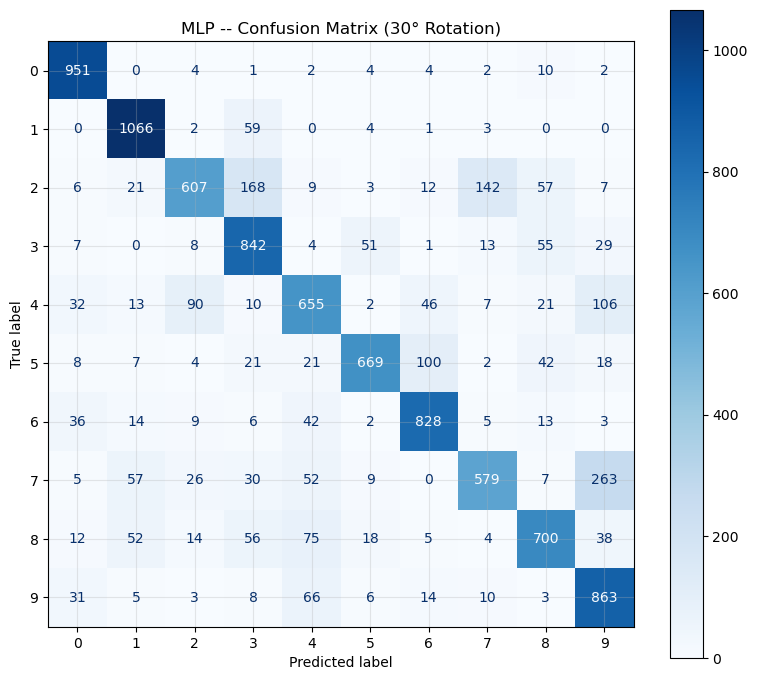

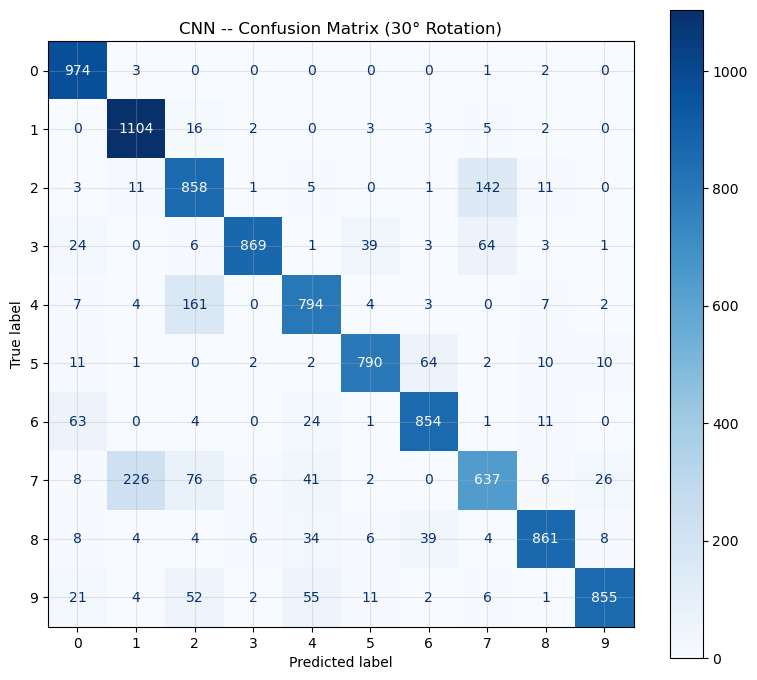

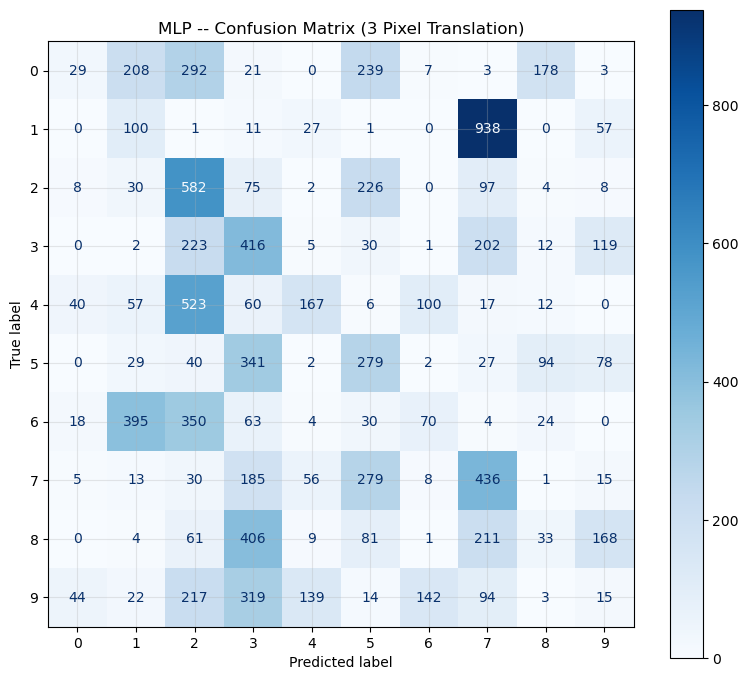

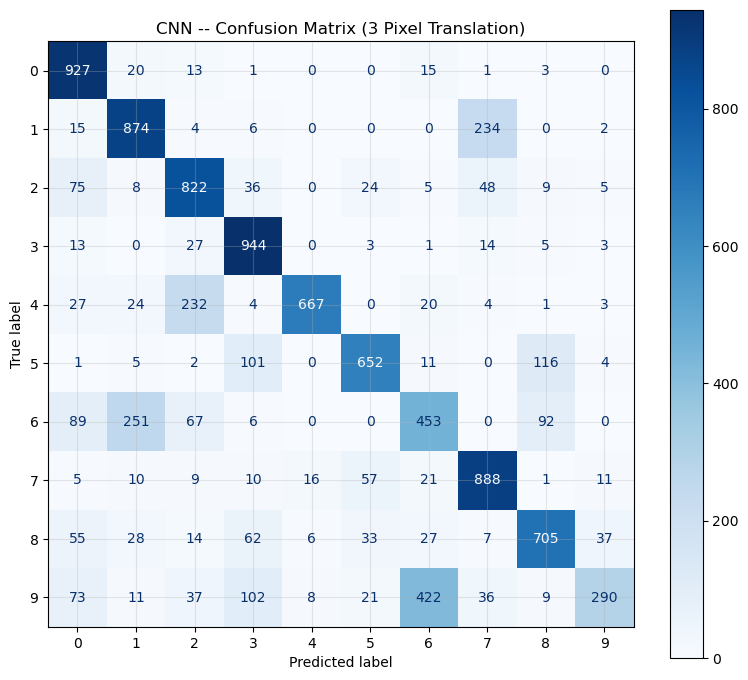

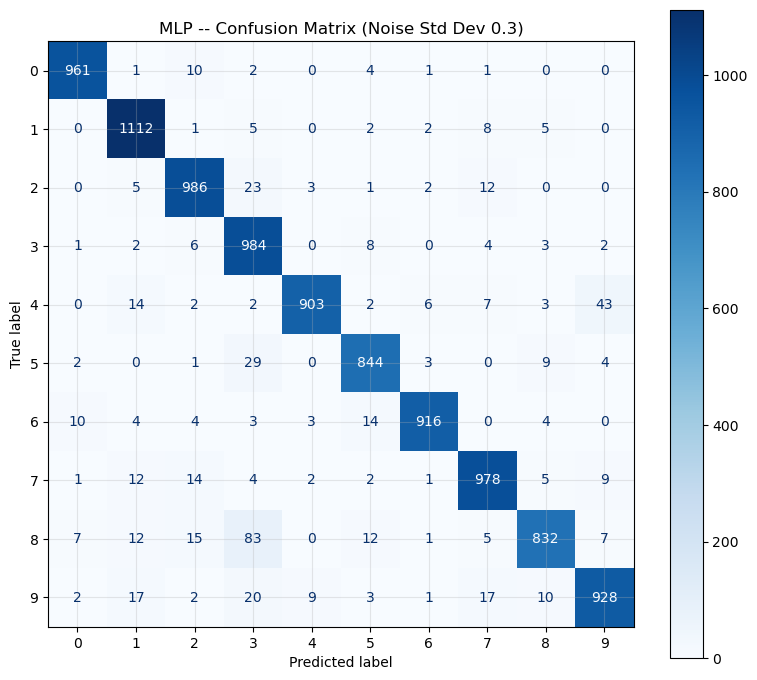

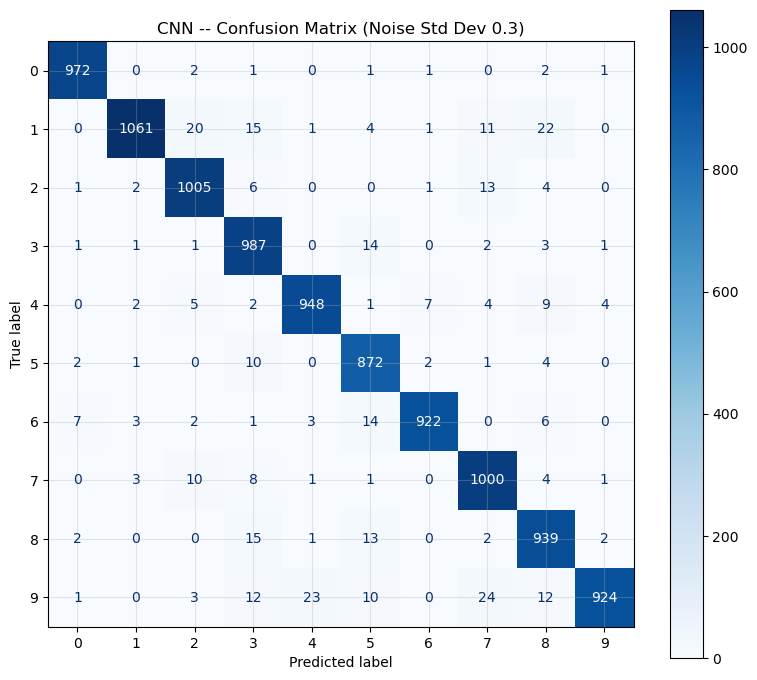

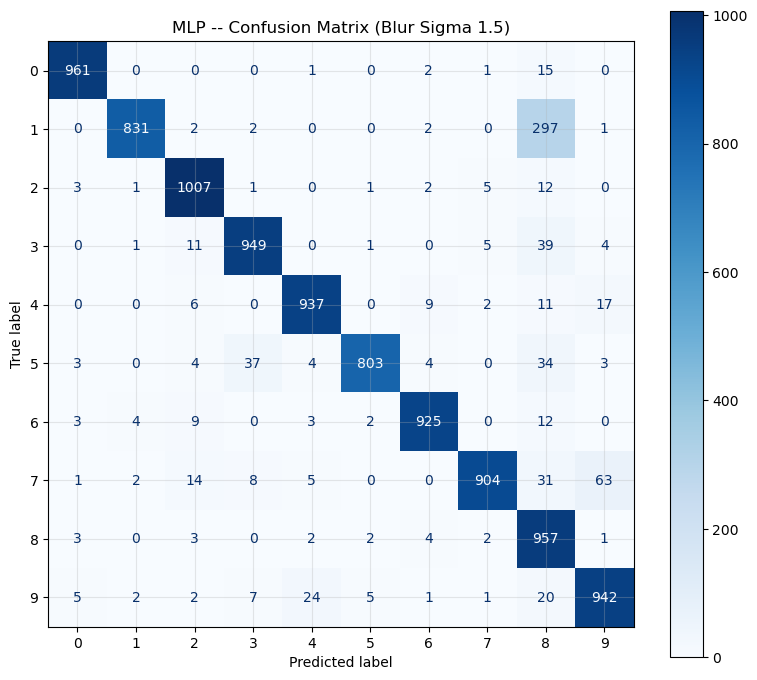

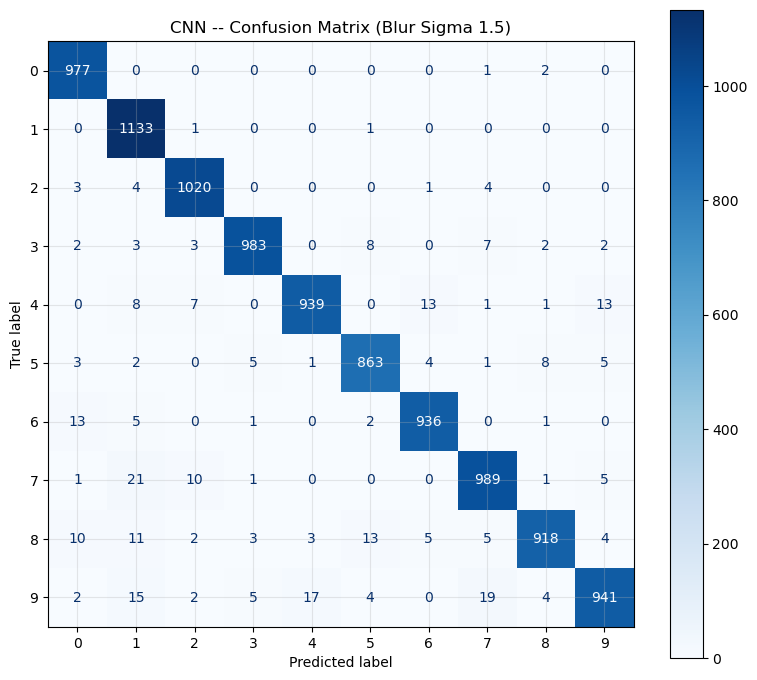

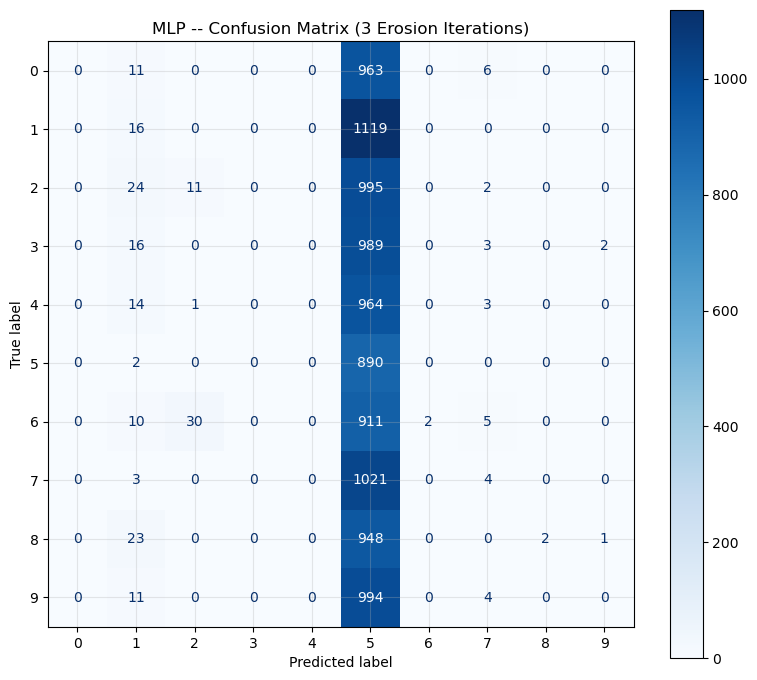

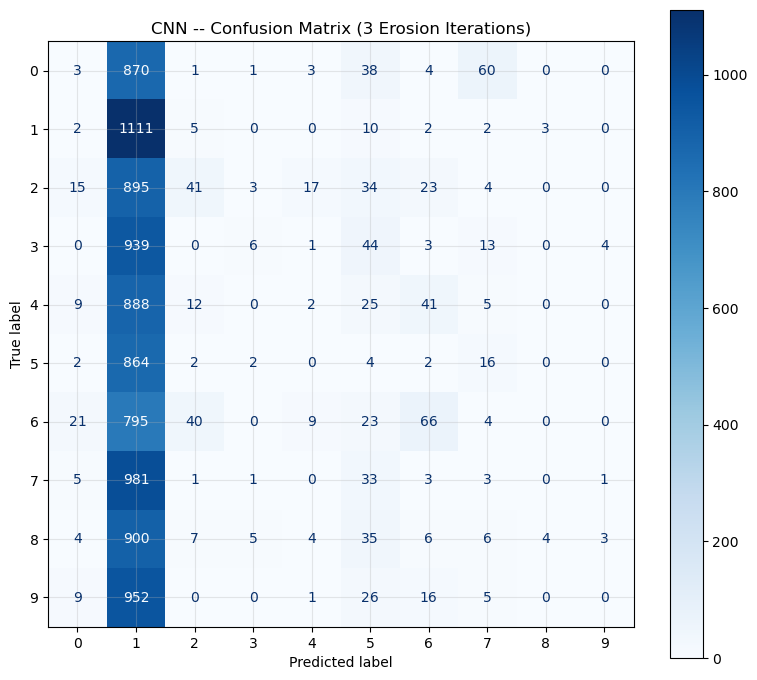

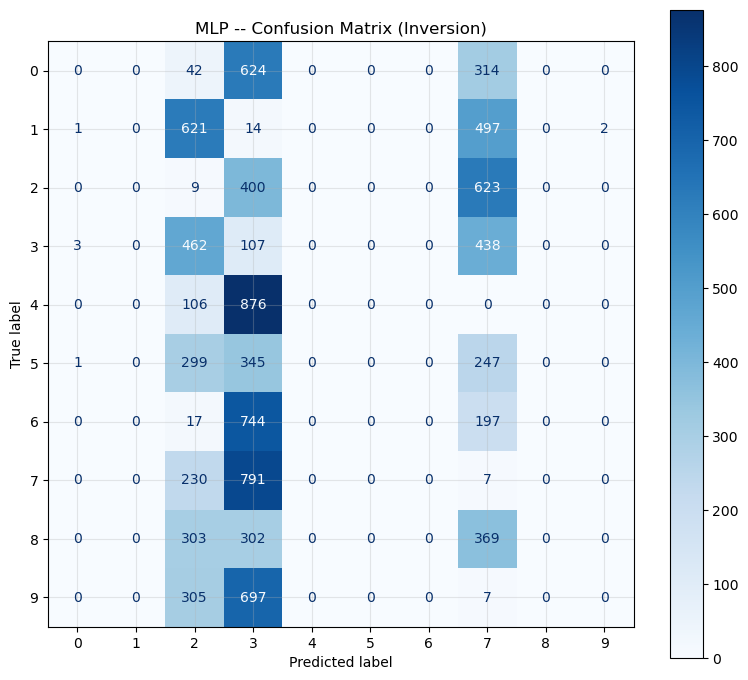

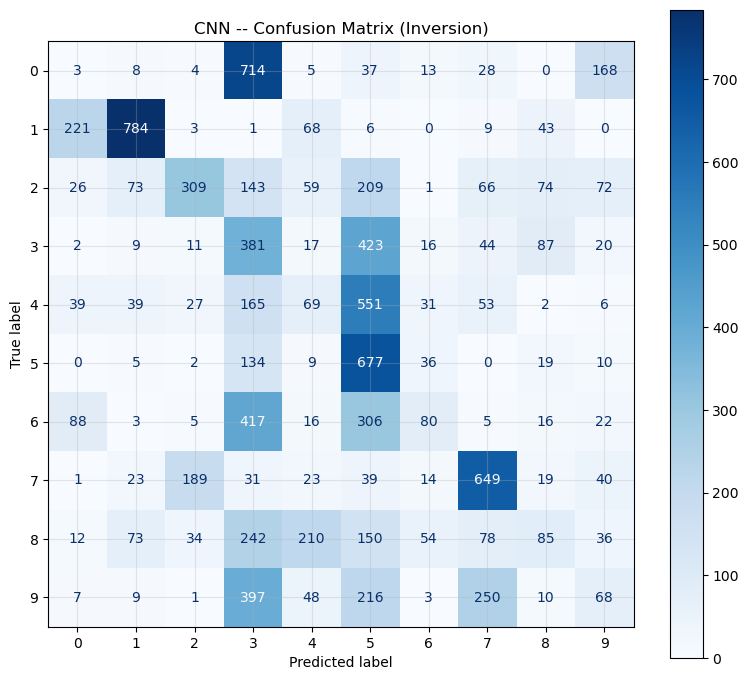

In [28]:
# Example: Confusion matrix for MLP on 30° rotated images
plot_confusion_matrix(mlp_tr_30, mlp_pr_30, title='MLP -- Confusion Matrix (30° Rotation)')
plot_confusion_matrix(cnn_tr_30, cnn_pr_30, title='CNN -- Confusion Matrix (30° Rotation)')

# TODO: Add confusion matrices for your other perturbation types.
# Which digit pairs get confused? Does the confusion make intuitive sense?

plot_confusion_matrix(mlp_tr_3, mlp_pr_3, title='MLP -- Confusion Matrix (3 Pixel Translation)')
plot_confusion_matrix(cnn_tr_3, cnn_pr_3, title='CNN -- Confusion Matrix (3 Pixel Translation)')    

plot_confusion_matrix(mlp_tr_0_3, mlp_pr_0_3, title='MLP -- Confusion Matrix (Noise Std Dev 0.3)')
plot_confusion_matrix(cnn_tr_0_3, cnn_pr_0_3, title='CNN -- Confusion Matrix (Noise Std Dev 0.3)')

plot_confusion_matrix(mlp_tr_1_5, mlp_pr_1_5, title='MLP -- Confusion Matrix (Blur Sigma 1.5)') 
plot_confusion_matrix(cnn_tr_1_5, cnn_pr_1_5, title='CNN -- Confusion Matrix (Blur Sigma 1.5)')

plot_confusion_matrix(mlp_tr_3e, mlp_pr_3e, title='MLP -- Confusion Matrix (3 Erosion Iterations)')
plot_confusion_matrix(cnn_tr_3e, cnn_pr_3e, title='CNN -- Confusion Matrix (3 Erosion Iterations)')

plot_confusion_matrix(mlp_tr_inv, mlp_pr_inv, title='MLP -- Confusion Matrix (Inversion)')
plot_confusion_matrix(cnn_tr_inv, cnn_pr_inv, title='CNN -- Confusion Matrix (Inversion)')

---

## 18. Results Summary

Bring all results together for your report.


FULL RESULTS TABLE
perturbation  intensity  mlp_accuracy  cnn_accuracy  accuracy_diff
       clean          0         98.03         99.11           1.08
    rotation          5         97.42         98.78           1.36
    rotation         10         96.27         98.31           2.04
    rotation         15         94.59         97.55           2.96
    rotation         20         90.70         95.50           4.80
    rotation         30         77.60         85.96           8.36
    rotation         45         49.77         60.90          11.13
 translation          1         91.21         98.22           7.01
 translation          2         56.89         92.49          35.60
 translation          3         21.27         72.22          50.95
 translation          4          6.16         39.17          33.01
 translation          5          3.25         12.81           9.56


C:\Users\nils1\AppData\Local\Temp\ipykernel_2868\3689772216.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = results.groupby('perturbation').apply(


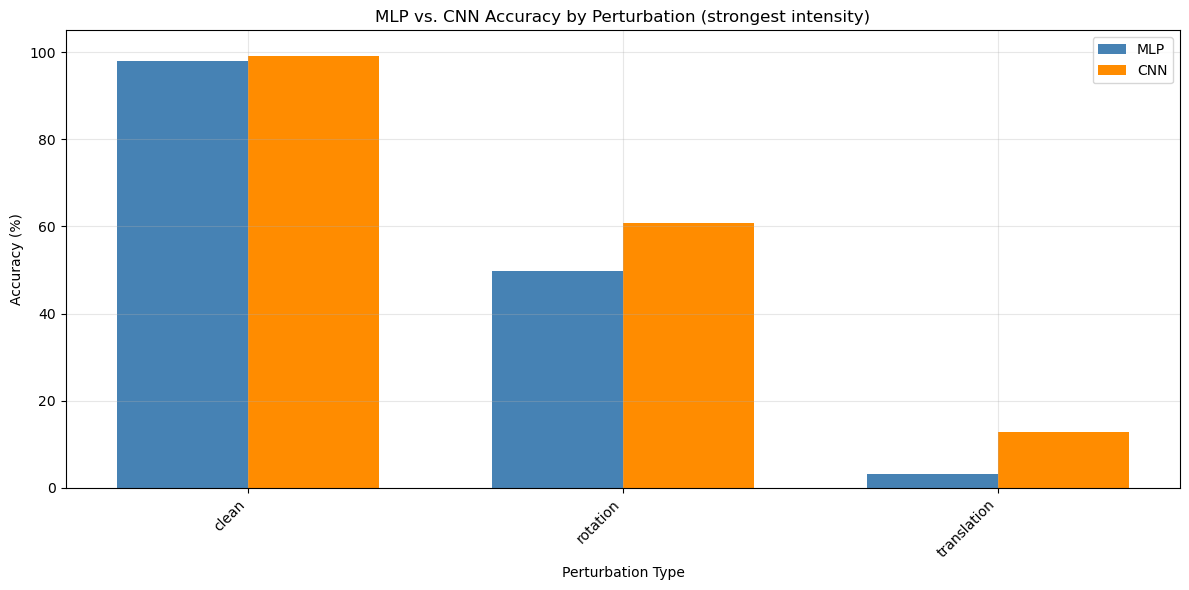

Results saved to rq2_results.csv


In [17]:
# Display full results table
print('\n' + '=' * 70)
print('FULL RESULTS TABLE')
print('=' * 70)
print(results.to_string(index=False))

# Summary bar chart: accuracy drop per perturbation type
# (using the strongest intensity for each perturbation)
summary = results.groupby('perturbation').apply(
    lambda g: g.loc[g['intensity'].idxmax()] if g['perturbation'].iloc[0] != 'clean' else g.iloc[0]
).reset_index(drop=True)

x = np.arange(len(summary))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, summary['mlp_accuracy'], width, label='MLP', color='steelblue')
ax.bar(x + width/2, summary['cnn_accuracy'], width, label='CNN', color='darkorange')
ax.set_xlabel('Perturbation Type')
ax.set_ylabel('Accuracy (%)')
ax.set_title('MLP vs. CNN Accuracy by Perturbation (strongest intensity)')
ax.set_xticks(x)
ax.set_xticklabels(summary['perturbation'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

# Save results
results.to_csv('rq2_results.csv', index=False)
print('Results saved to rq2_results.csv')

---

## 19. Optional Extension: Can You Build a More Robust CNN?

The template provides a simple 3-layer CNN. If you finish the core comparison early,
try modifying the CNN architecture and test whether it improves robustness.

Ideas: deeper networks, larger kernels (5x5), more filters, Global Average Pooling, or average pooling instead of max pooling.

Pick **one or two** changes, retrain on clean MNIST, and test on the same perturbed sets.  
Does the architecture matter, or are the weaknesses fundamental?

In [18]:
# TODO (optional): Experiment with a different CNN architecture.
# For example:
#
# class CNN_v2(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.features = nn.Sequential(
#             nn.Conv2d(1, 32, kernel_size=5, padding=2),  # larger kernel
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, kernel_size=5, padding=2),
#             nn.ReLU(),
#             nn.MaxPool2d(2),
#         )
#         self.classifier = nn.Sequential(
#             nn.AdaptiveAvgPool2d(1),  # Global Average Pooling
#             nn.Flatten(),
#             nn.Linear(64, 10)
#         )
#     def forward(self, x):
#         if x.dim() == 3: x = x.unsqueeze(1)
#         x = self.features(x)
#         return self.classifier(x)
#     def count_parameters(self):
#         return sum(p.numel() for p in self.parameters() if p.requires_grad)
#
# Train and evaluate on the same perturbed sets, then compare with the original CNN.

pass

---

## 20. Key Findings

Summarize your main observations here (these will feed into your report).

**TODO:** Write a brief summary:

1. **Which perturbations hurt the MLP most?** Why? (Think about what MLPs rely on.)
2. **Which perturbations hurt the CNN most?** Why? (Think about what CNNs rely on.)
3. **Where was the CNN clearly better?** What architectural property explains this?
4. **Where did both models fail equally?** What does this tell you about their shared limitations?
5. **Most surprising finding?** Something you didn't expect before running the experiments.
6. **If you could add data augmentation to fix one weakness, which perturbation would you target first?**